In [1]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '4'   #set threads
os.environ['MKL_NUM_THREADS'] = '4'
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['NUMEXPR_NUM_THREADS'] = '4'

In [2]:
# Core scverse libraries
import scanpy as sc
import anndata as ad

# Data retrieval
import pooch
import pandas as pd
#import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
## 去除批次效应 
## harmony
import scanpy.external as sce


In [3]:
# 打印所有相关线程环境变量
print("OPENBLAS_NUM_THREADS =", os.getenv('OPENBLAS_NUM_THREADS'))
print("MKL_NUM_THREADS =", os.getenv('MKL_NUM_THREADS'))
print("OMP_NUM_THREADS =", os.getenv('OMP_NUM_THREADS'))

OPENBLAS_NUM_THREADS = 4
MKL_NUM_THREADS = 4
OMP_NUM_THREADS = 4


In [4]:
sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=True,  #是否添加框线
    figsize=(4, 4)
)


In [194]:
adata=sc.read_h5ad('./adata_pcos.h5ad')

In [119]:
adata.X=adata.layers['counts'].copy()  

In [81]:
#2.计算双细胞
sc.pp.scrublet(adata, expected_doublet_rate = 0.05,threshold=0.25,batch_key = "sample")

In [82]:
adata

AnnData object with n_obs × n_vars = 62413 × 18144
    obs: 'sample', 'n_genes', 'group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden_0.5', 'bbknn_leiden_0.5', 'harmony_leiden_0.5', 'harmony_leiden_0.2', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'bbknn_leiden_0.5', 'bbknn_leiden_0.5_colors', 'group_colors', 'harmony_leiden_0.2', 'harmony_leiden_0.2_colors', 'harmony_leiden_0.5', 'harmony_leiden_0.5_colors

In [ ]:
os.mkdir('./04_double_cell_remove/')

In [83]:
data_dir='./04_double_cell_remove/'

In [84]:
adata.obs[["doublet_score","predicted_doublet"]].to_csv('{}adata_scrublet.csv'.format(data_dir))


In [86]:
### 重新读入之前处理过的数据

adata=sc.read_h5ad('./adata_pcos.h5ad')

In [89]:
results=pd.read_csv('./04_double_cell_remove/adata_scrublet.csv',index_col=0)
print(results.head())

                                          doublet_score  predicted_doublet
GSM8302650_AAACCCAAGCATGCGA-1-GSM8302650       0.035606              False
GSM8302650_AAACCCAAGGCAATGC-1-GSM8302650       0.037412              False
GSM8302650_AAACCCAAGGCAGGGA-1-GSM8302650       0.047022              False
GSM8302650_AAACCCACATAGAAAC-1-GSM8302650       0.052278              False
GSM8302650_AAACCCACATCGCTGG-1-GSM8302650       0.069388              False


In [91]:
adata.obs.index.equals(results.index)

True

In [92]:
adata.obs['doublet_score'] = results['doublet_score']
adata.obs['predicted_doublet'] = results['predicted_doublet']

In [93]:
adata

AnnData object with n_obs × n_vars = 62413 × 18144
    obs: 'sample', 'n_genes', 'group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden_0.5', 'bbknn_leiden_0.5', 'harmony_leiden_0.5', 'harmony_leiden_0.2', 'Major_annotation', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'Major_annotation_colors', 'bbknn_leiden_0.5', 'bbknn_leiden_0.5_colors', 'dea_manual_1', 'dendrogram_harmony_leiden_0.2', 'group_colors', 'ha

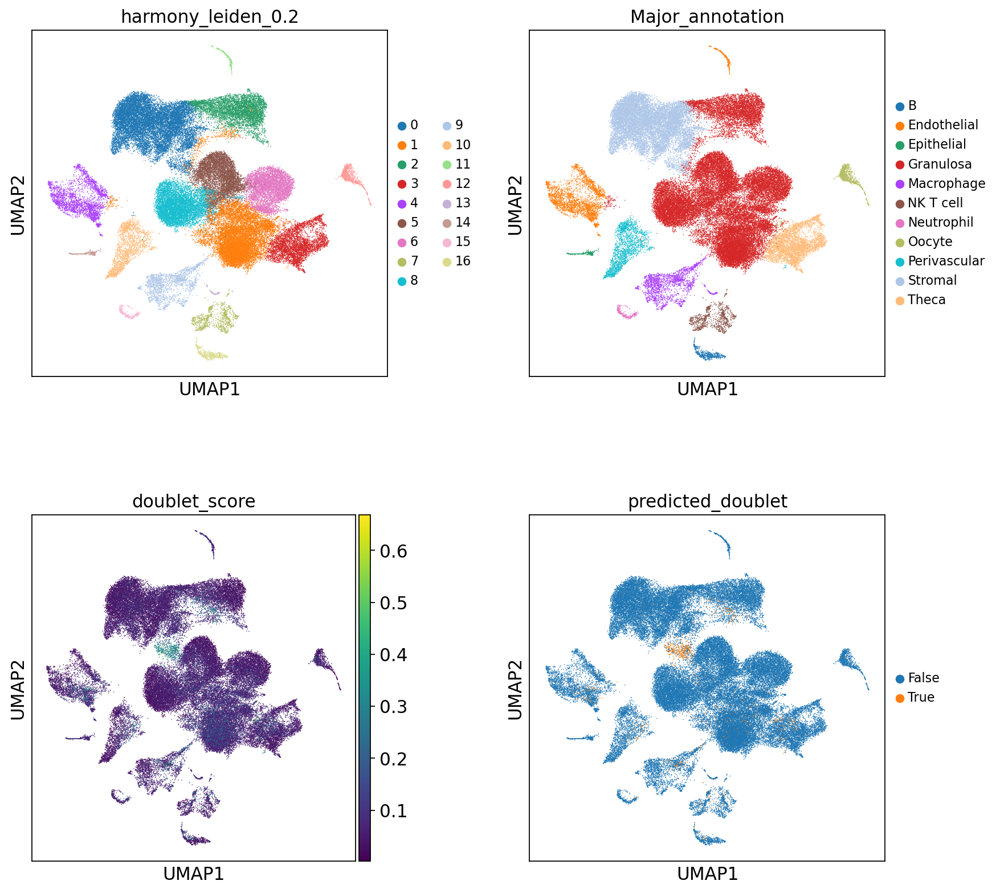

In [96]:
fig, axs = plt.subplots(2,2,figsize=(12,12), gridspec_kw={'wspace':0.4,'hspace':0.4})
# 在每个子图上绘制UMAP
ax1_dict=sc.pl.umap(adata, color='harmony_leiden_0.2',frameon=True,legend_fontsize=10,   ax=axs[0, 0], show=False)
ax2_dict=sc.pl.umap(adata, color='Major_annotation',frameon=True,legend_fontsize=10,   ax=axs[0, 1], show=False)
ax3_dict=sc.pl.umap(adata, color='doublet_score',frameon=True,legend_fontsize=10,   ax=axs[1, 0], show=False)
ax4_dict=sc.pl.umap(adata, color='predicted_doublet',frameon=True,legend_fontsize=10,   ax=axs[1, 1], show=False)

plt.show()

In [98]:
#3.比较前后两次的双细胞预测情况
pd.crosstab(adata.obs.predicted_doublet, adata.obs.Major_annotation)

Major_annotation,B,Endothelial,Epithelial,Granulosa,Macrophage,NK T cell,Neutrophil,Oocyte,Perivascular,Stromal,Theca
predicted_doublet,,,,,,,,,,,
False,462,2956,220,34669,1970,970,259,791,1853,13131,4088
True,20,83,1,380,54,36,8,5,45,333,79


/tmp/ipykernel_2360343/2380611894.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = df.groupby(['Major_annotation', 'predicted_doublet']).size().unstack(fill_value=0)
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont:

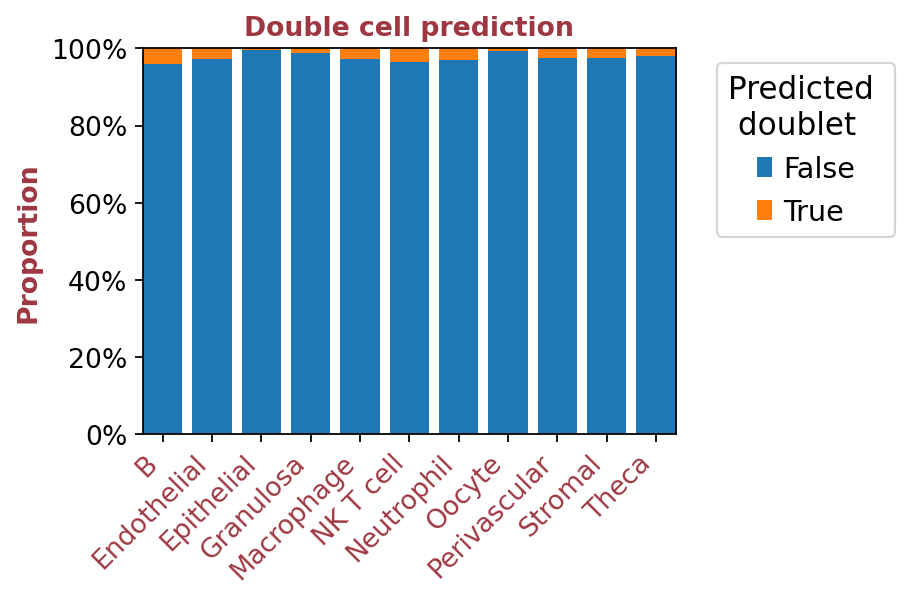

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
#plt.rcParams['font.family'] = 'Arial'
# 假设 adata 已经加载并包含了必要的 obs 信息
# 确保 'cell_type' 和 'sample' 在 adata.obs 中

# 创建一个 DataFrame，包含 cell_type 和 sample 列
df = adata.obs[['Major_annotation', 'predicted_doublet']]

# 计算每个样本中每种细胞类型的数量
cell_counts = df.groupby(['Major_annotation', 'predicted_doublet']).size().unstack(fill_value=0)

# 计算每个样本中每种细胞类型的百分比
cell_percentages = cell_counts.div(cell_counts.sum(axis=1), axis=0)

# 绘制堆叠柱状图
fig, ax = plt.subplots(figsize=(6, 4))

# 使用 seaborn 的 stacked bar plot 功能 (需要通过累积和手动实现)
bottom = None
for idx, col in enumerate(cell_percentages.columns):
    if idx == 0:
        ax.bar(cell_percentages.index, cell_percentages[col], label=col)
        bottom = cell_percentages[col]
    else:
        ax.bar(cell_percentages.index, cell_percentages[col], bottom=bottom, label=col)
        bottom += cell_percentages[col]

# 设置图表标题和标签
ax.set_title('Double cell prediction',weight='bold',color='#9e3741',fontsize=12)
ax.set_xlabel(None,color='#9e3741',weight='bold',fontsize=12)
ax.set_ylabel('Proportion',color='#9e3741',weight='bold',fontsize=12)
ax.grid(False)  # 完全移除网格线
# 或者
# ax.grid(True, linestyle='--')  # 将网格线变为虚线
# 旋转 x 轴标签 45 度并右对齐
plt.xticks(rotation=45, ha='right',color='#9e3741',fontsize=12)
plt.yticks(fontsize=12)
# 添加图例
plt.legend(title='Predicted \n doublet', bbox_to_anchor=(1.05, 1), loc='upper left')
# 将图形两侧紧贴 y 轴
#ax.spines['left'].set_position(('data', -0.05))  # 调整左侧脊柱位置
#ax.spines['right'].set_visible(False)  # 隐藏右侧脊柱
#ax.spines['top'].set_visible(False)  # 隐藏顶部脊柱
# 修改 y 轴刻度标签为百分比格式（如 0% 到 100%）
def percent_formatter(x, pos):
    return f"{int(x * 100)}%"
ax.yaxis.set_major_formatter(mticker.FuncFormatter(percent_formatter))
# 可选：设置 y 轴刻度间隔为每 0.2（即 0%, 20%, ..., 100%）
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
# 设置 y 轴范围从 0 到 1，并且没有额外的扩展
ax.set_ylim(0, 1)
ax.margins(x=0)  # 消除 x 轴的空白区域
# 调整布局以避免遮挡
plt.tight_layout()
# 显示图形
plt.show()

In [102]:
adata.write('./adata_pcos.h5ad')

In [124]:
#### 重新读入数据

adata=sc.read_h5ad('./adata_pcos.h5ad')

In [195]:
adata.X=adata.layers['counts'].copy()  ###提取counts矩阵 重新降维聚类分群
### 提取单个细胞的数据
adata = adata[adata.obs.predicted_doublet==False, :]

#### 标准流程
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw=adata.copy()   ### 保存标准化之后的矩阵
#sc.pp.highly_variable_genes(adata,min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.highly_variable_genes(adata, flavor='seurat', batch_key='sample', n_top_genes=2000)
#adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack")
####去批次
sce.pp.harmony_integrate(adata,key='sample',basis='X_pca',plot_convergence=True)
sc.pp.neighbors(adata,use_rep='X_pca_harmony', n_neighbors=10, n_pcs=30)
sc.tl.umap(adata,random_state=42)
adata.obsm['X_umap_harmony_d']=adata.obsm['X_umap']
adata.uns['umap_harmony_d']=adata.uns['umap']

In [197]:
### 划分亚群 分辨率 0.2
sc.tl.leiden(adata,flavor="igraph",n_iterations=2,resolution=0.2,key_added='d_harmony_leiden_0.2')

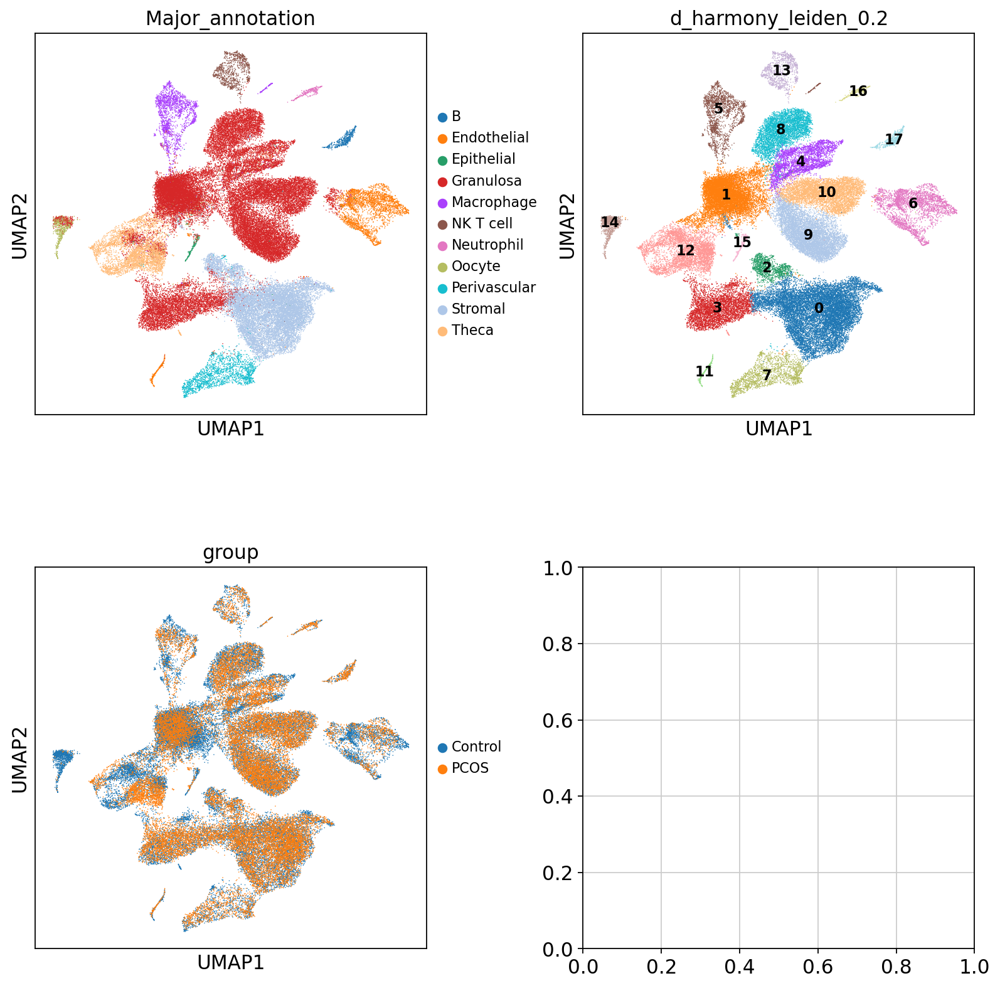

In [198]:
fig, axs = plt.subplots(2,2,figsize=(12,12), gridspec_kw={'wspace':0.4,'hspace':0.4})
# 在每个子图上绘制UMAP
ax1_dict=sc.pl.umap(adata, color='Major_annotation',
                    frameon=True,legend_fontsize=10,   ax=axs[0,0], show=False)
ax3_dict=sc.pl.umap(adata, color='group',
                    frameon=True,legend_fontsize=10,   ax=axs[1,0], show=False)
ax3_dict=sc.pl.umap(adata, color='d_harmony_leiden_0.2',legend_loc="on data",
                    frameon=True,legend_fontsize=10,   ax=axs[0,1], show=False)
plt.show()

In [200]:
#3.计算PCOS和正常组之间的细胞比例
pd.crosstab(adata.obs.group,adata.obs.Major_annotation)

Major_annotation,B,Endothelial,Epithelial,Granulosa,Macrophage,NK T cell,Neutrophil,Oocyte,Perivascular,Stromal,Theca
group,,,,,,,,,,,
Control,205,2096,158,19537,1262,534,116,747,963,6518,2114
PCOS,257,860,62,15132,708,436,143,44,890,6613,1974


In [201]:
adata.write('./04_double_cell_remove/adata_after_double.h5ad')

In [135]:
adata=sc.read_h5ad('./04_double_cell_remove/adata_after_double.h5ad')

### 差异分析

In [136]:
adata.uns['log1p']['base'] =None
sc.tl.rank_genes_groups(
    adata, "d_harmony_leiden_0.2", method="wilcoxon",key_added='dea_manual_d_1'
    ,use_raw=True  #默认就是用这个
)

In [139]:
### 导出差异分析结果
groups=adata.uns['dea_manual_d_1']['names'].dtype.names

with pd.ExcelWriter('./05_Major_annotation/d_harmony_leiden_0.2_dea_results.xlsx') as writer:
    for group in groups:
        df=sc.get.rank_genes_groups_df(adata,group=group,key='dea_manual_d_1')
        df['group']=group
        ### 保存excel表格
        df.to_excel(writer,sheet_name=group)
    



In [8]:
### annotation cell types

cl_annotation = {
    "0": "Stromal", #
    "1": "Granulosa", #
    "2": "Stromal", # 
    "3": 'Granulosa',  #Mural cells Granulosa
    "4": 'Granulosa', #
    "5": "Macrophage", #
    "6": "Endothelial", #
    "7": "Perivascular", #
    "8": "Granulosa", #
    "9": "Granulosa", #
    "10": "Granulosa",
    "11": "Endothelial", #
    "12":  "Theca",#
    "13": "NK T cell", #
    "14": "Oocyte", #
    "15": "Epithelial",#
    "16": "Neutrophil",
    "17": "B",
}
adata.obs["Major_annotation_d"] = adata.obs['d_harmony_leiden_0.2'].map(cl_annotation)


In [9]:
### 手动注释2
marker_genes_dict1 = {
    #'Germ':['Oct4','Par6'],
    'Endothelial': ['Cldn5','Ebf1','Flt1'], #单核细胞
    'Granulosa': ['Fst','Camta1'], #颗粒细胞
    'Thecal': ['Cyp17a1'], #单核细胞
    'Stroma': ['Pdgfra'], #单核细胞
    'Perivascular': ['Rgs5'], #单核细胞
    'Immune': ['Cd52'], #单核细胞
    'NK cells': ['Nkg7'], #NK 细胞
    'B cells': ['Cd19','Ms4a1', 'Cd79a', 'Cd79b'], #B 细胞
    'T cells': ['Cd3d',  'Cd3g','Cd8a'], #T 细胞
    #'Dendritic cells': ['Itgax'], #树突状细胞
    'Monocytes': ['Cd68','Cd14',], #单核细胞
    

}

### 手动注释2
marker_genes_dict2 = {
    'Epithelial':['Upk1b','Gpm6a'],
    'Endothelial': ['Cd34'], #单核细胞
    'Stroma': ['Pdgfra','Col1a1','Notch3'], #单核细胞
    'Thecal': ['Cyp17a1','Srd5a1'], #单核细胞
    'Granulosa': ['Amh','Fst','Camta1'], #颗粒细胞
    'Oocytes':['Zp3'],
    'Luteal':['Ptgfr'],
    'Perivascular': ['Rgs5'], #单核细胞
    'Immune': ['Ptprc','Cd52'], #单核细胞
    'T cells': ['Cd3d',  'Cd3g','Cd8a'], #T 细胞
    'B cells': ['Cd79a', 'Cd79b'], #B 细胞
    'NK cells': ['Nkg7',' Klrb1b','Ncr1'], #NK 细胞
    'Dendritic cells': ['Flt3','Clec9a','Cd209a'], #树突状细胞
    'Monocytes': ['Cd68','Cd14',], #单核细胞
    

}

marker_genes_dict3 = {
    #'Germ':['Oct4','Par6'],
    'Epithelial':['Upk1b','Gpm6a','Krt19'],
    'Endothelial': ['Cldn5','Ebf1','Flt1'], #单核细胞
        'Oocyte':['Ooep','Ddx4','Bmp15'],
    'Granulosa': ['Fst','Camta1','Amh','Con2','Foxo1'], #颗粒细胞
    'Cumulus':['Hsd17b1','Inhbb','Ihh'], #卵丘细胞
    'Luteum':['Cyp11a1','Fdx1','Star'],
    'Mural':['Cited2','Aldh1a1'],
    'Primitive':['Wnt4','Wt1'],

    'Thecal': ['Cyp17a1'], #壁细胞
    'Stroma': ['Pdgfra','Dcn','Lum'], #单核细胞
    'Perivascular': ['Rgs5','Rergl','Mcam'], #单核细胞
    'Immune': ['Cd52'], #单核细胞
    'NK cells': ['Nkg7'], #NK 细胞
    'B cells': ['Cd19','Ms4a1', 'Cd79a', 'Cd79b'], #B 细胞
    'T cells': ['Cd3d',  'Cd3g','Cd8a'], #T 细胞
    #'Dendritic cells': ['Itgax'], #树突状细胞
    'Monocytes': ['Cd68','Cd14',], #单核细胞
    
    

}

In [10]:
marker_genes_in_data = {}
for ct, markers in marker_genes_dict3.items():
    markers_found = []
    for marker in markers:
        if marker in adata.var.index:
            markers_found.append(marker)
    marker_genes_in_data[ct] = markers_found

In [11]:
cell_cts = marker_genes_in_data.keys()
print(cell_cts )

dict_keys(['Epithelial', 'Endothelial', 'Oocyte', 'Granulosa', 'Cumulus', 'Luteum', 'Mural', 'Primitive', 'Thecal', 'Stroma', 'Perivascular', 'Immune', 'NK cells', 'B cells', 'T cells', 'Monocytes'])


EPITHELIAL:


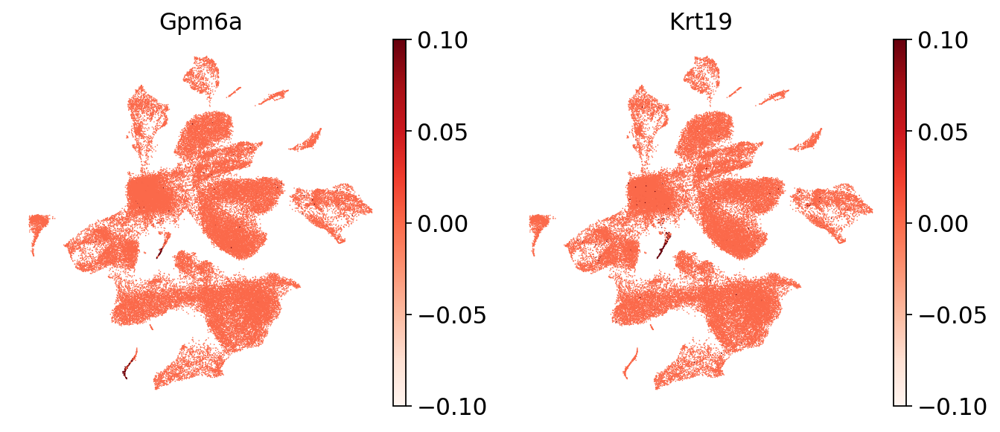





ENDOTHELIAL:


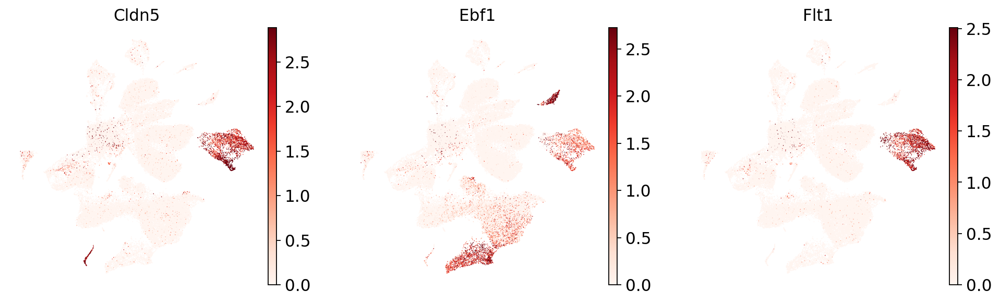





OOCYTE:


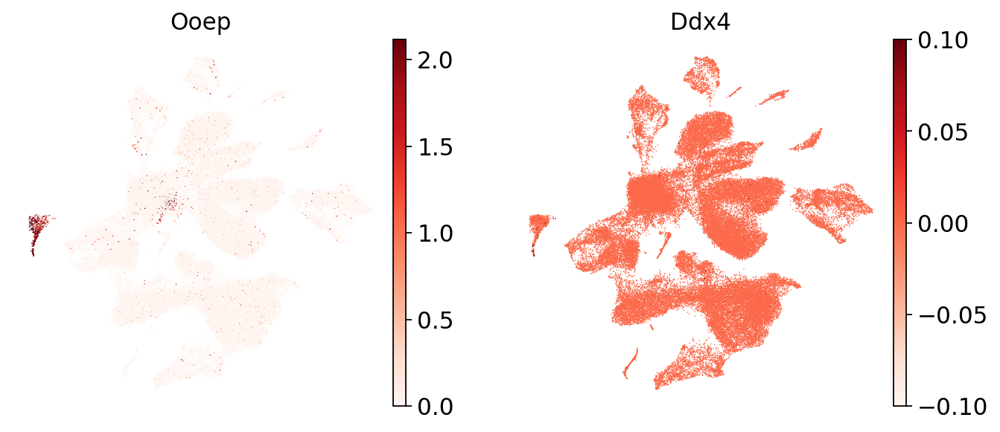





GRANULOSA:


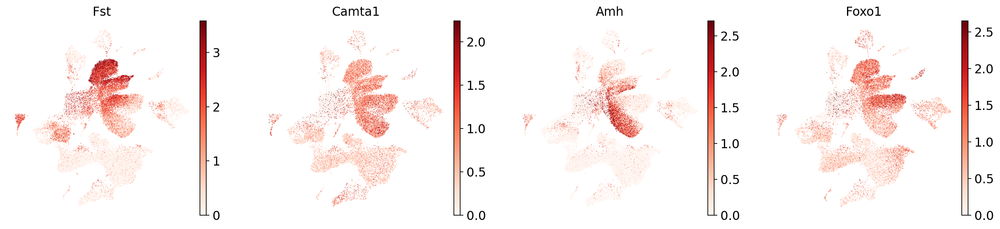





CUMULUS:


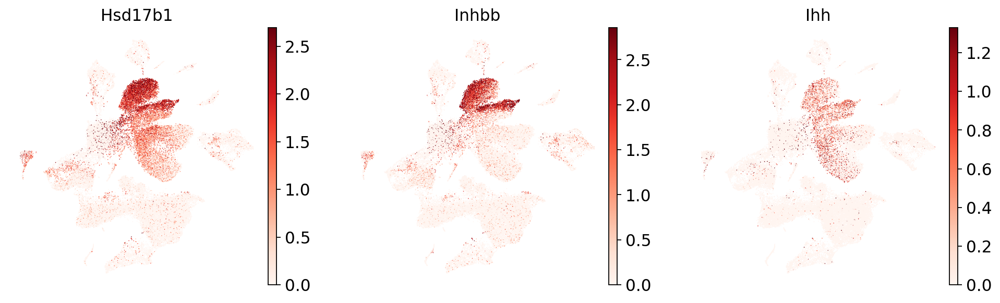





LUTEUM:


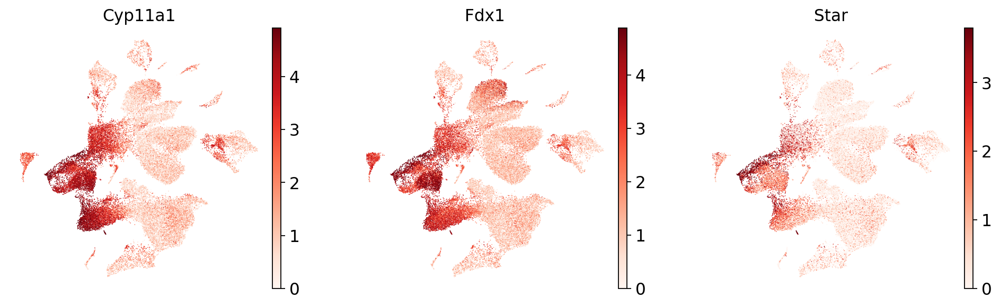





MURAL:


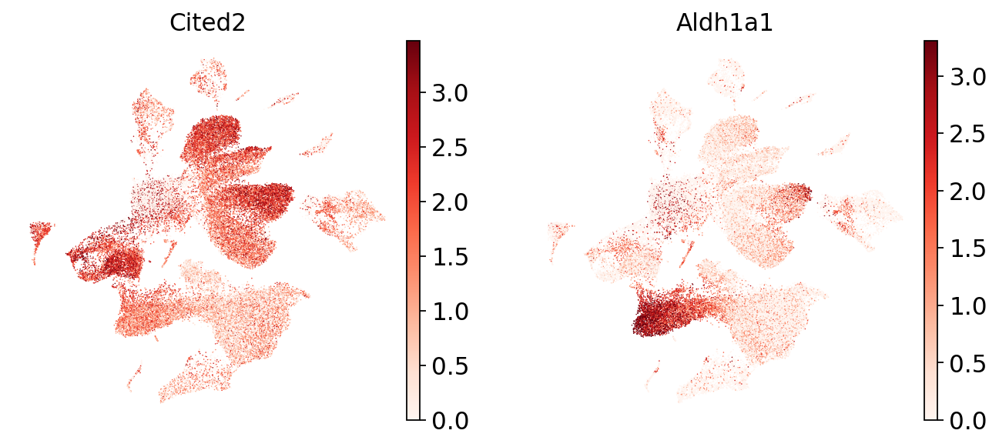





PRIMITIVE:


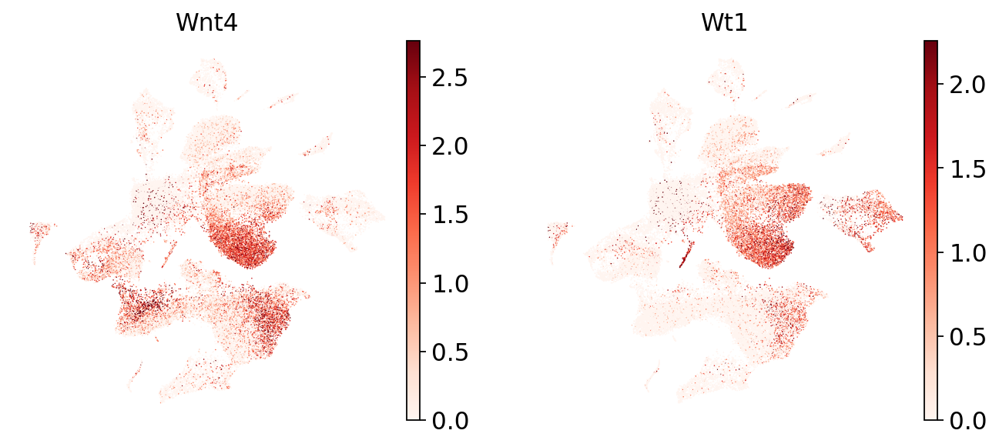





THECAL:


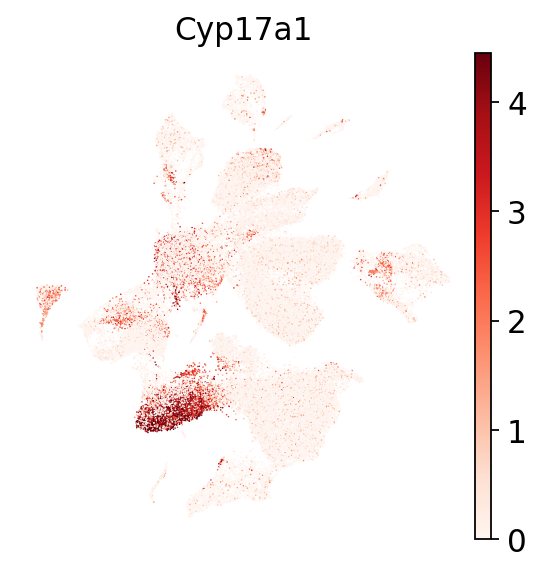





STROMA:


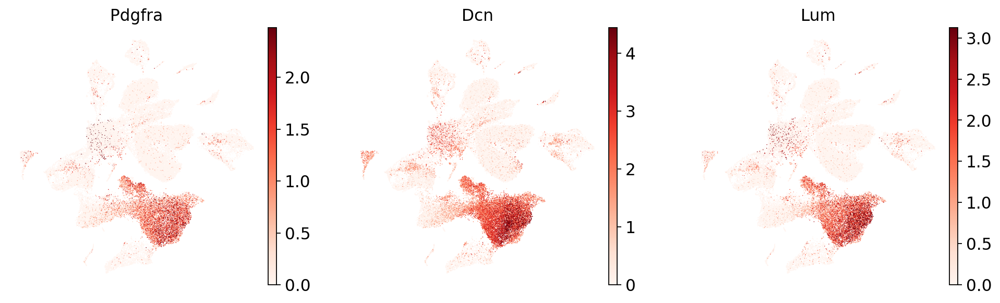





PERIVASCULAR:


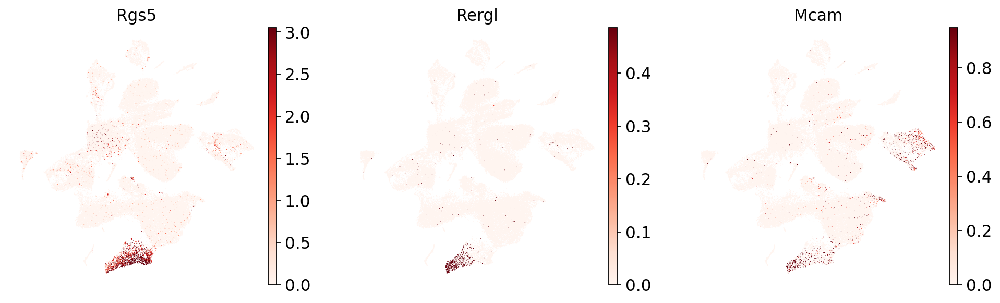





IMMUNE:


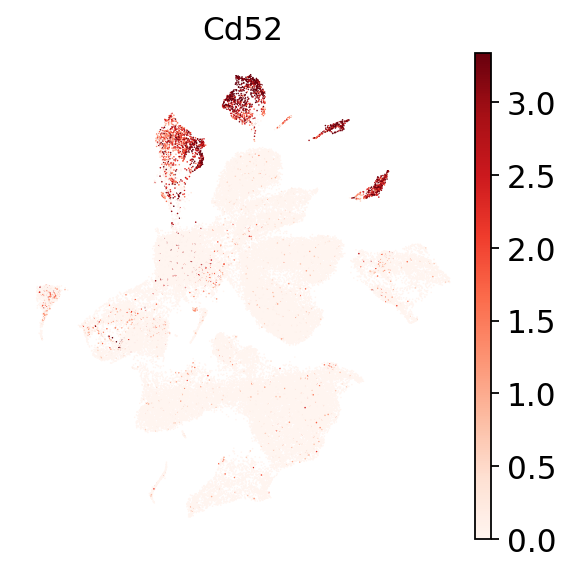





NK CELLS:


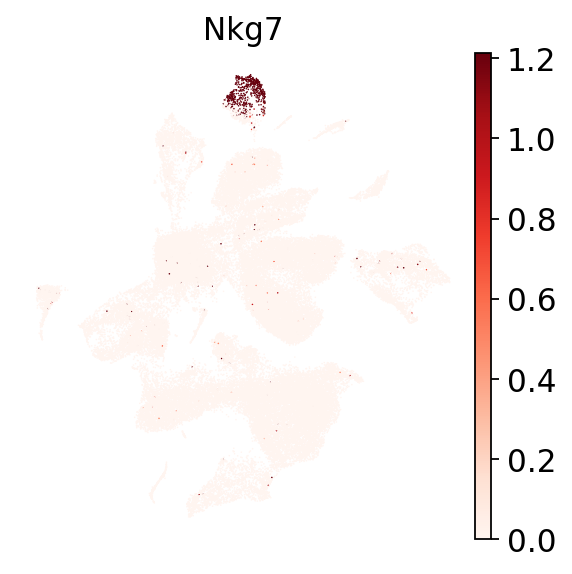





B CELLS:


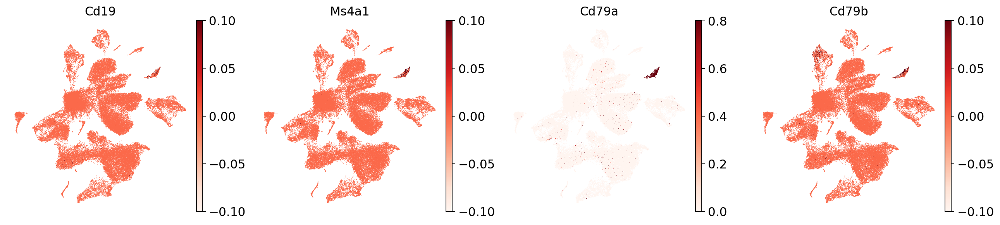





T CELLS:


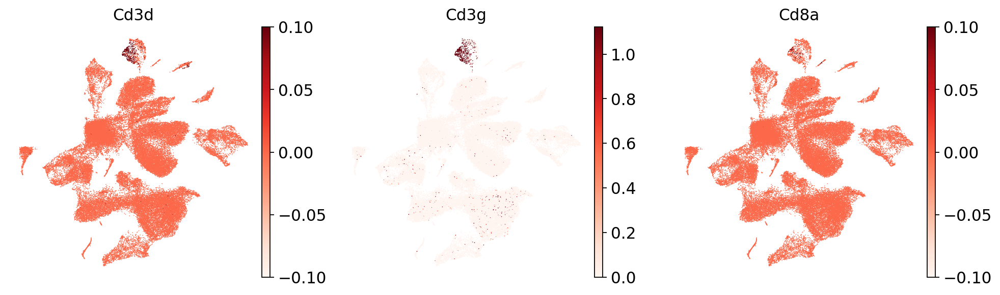





MONOCYTES:


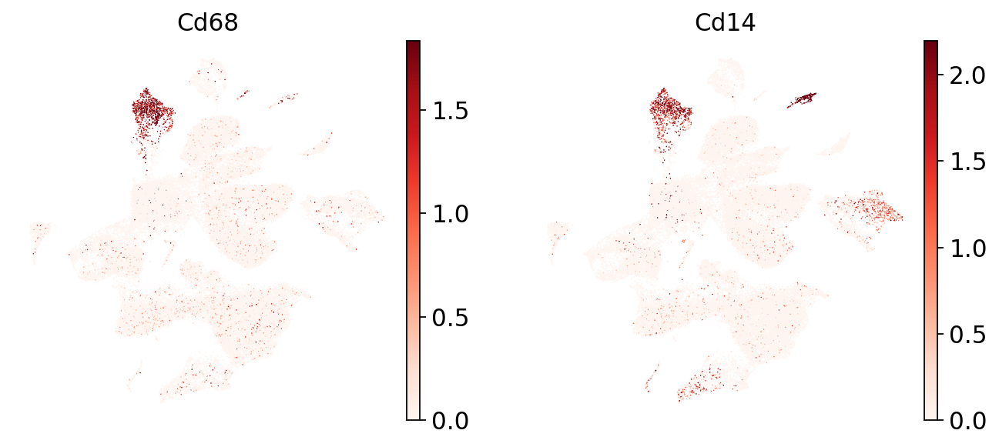

In [12]:
for ct in cell_cts :
    print(f"{ct.upper()}:")  # print cell subtype name
    sc.pl.umap(
        adata,
        color=marker_genes_in_data[ct],
        vmin=0,
        vmax="p99",  # set vmax to the 99th percentile of the gene count instead of the maximum, to prevent outliers from making expression in other cells invisible. Note that this can cause problems for extremely lowly expressed genes.
        sort_order=False,  # do not plot highest expression on top, to not get a biased view of the mean expression among cells
        frameon=False,
        cmap="Reds",  # or choose another color map e.g. from here: https://matplotlib.org/stable/tutorials/colors/colormaps.html
    )
    print("\n\n\n")  # print white space for legibility

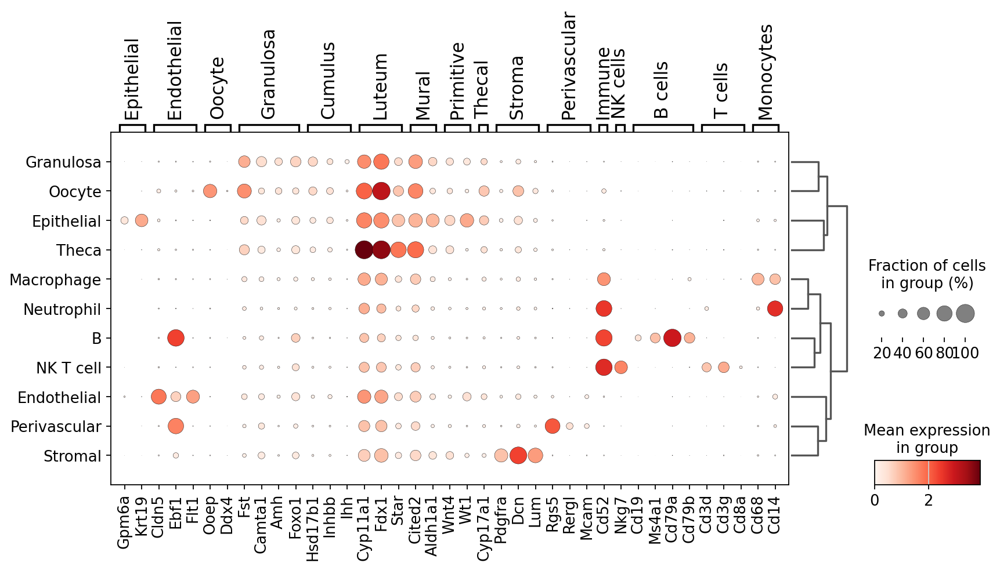

In [13]:
sc.pl.dotplot(adata,marker_genes_in_data,groupby='Major_annotation_d',dendrogram=True,figsize=(12,5)
             #, standard_scale="var"
             )

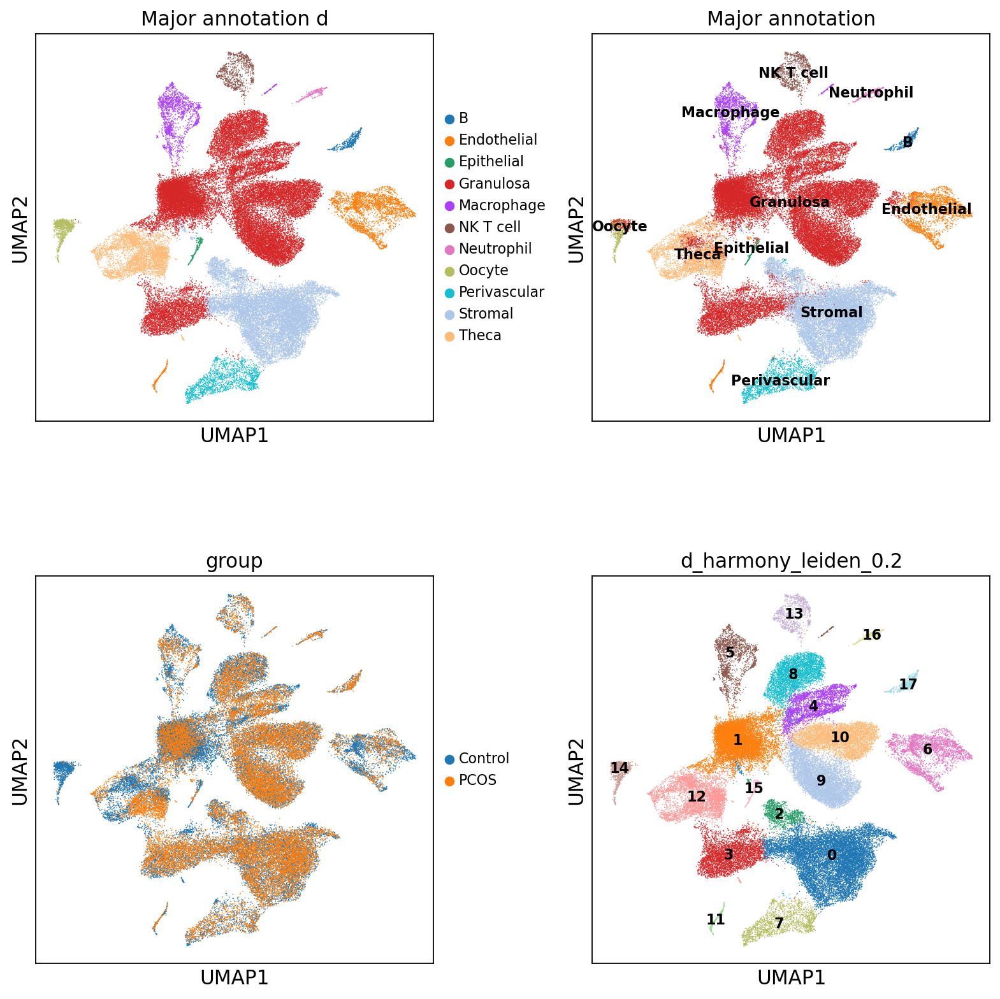

In [14]:
### 初步注释之后

fig, axs = plt.subplots(2,2,figsize=(12,12), gridspec_kw={'wspace':0.4,'hspace':0.4})
# 在每个子图上绘制UMAP
ax1_dict=sc.pl.umap(adata, color='Major_annotation_d',title='Major annotation d',
                    frameon=True,legend_fontsize=10,   ax=axs[0,0], show=False)
ax2_dict=sc.pl.umap(adata, color='Major_annotation',title='Major annotation',legend_loc="on data",
                    frameon=True,legend_fontsize=10,   ax=axs[0,1], show=False)
ax3_dict=sc.pl.umap(adata, color='group',
                    frameon=True,legend_fontsize=10,   ax=axs[1,0], show=False)
ax3_dict=sc.pl.umap(adata, color='d_harmony_leiden_0.2',legend_loc="on data",
                    frameon=True,legend_fontsize=10,   ax=axs[1,1], show=False)
plt.show()

In [15]:
#3.计算PCOS和正常组之间的细胞比例
print(pd.crosstab(adata.obs.group,adata.obs.Major_annotation_d))
adata.write('./04_double_cell_remove/adata_after_double.h5ad')  ### 注释过的数据

Major_annotation_d    B  Endothelial  Epithelial  Granulosa  Macrophage  \
group                                                                     
Control             188         2187         148      18431        1148   
PCOS                252          943          50      14672         708   

Major_annotation_d  NK T cell  Neutrophil  Oocyte  Perivascular  Stromal  \
group                                                                      
Control                   494          98     961           929     7044   
PCOS                      424         139      23           858     7188   

Major_annotation_d  Theca  
group                      
Control              2622  
PCOS                 1862  


/tmp/ipykernel_1379666/1443178273.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = df.groupby(['group', 'Major_annotation_d']).size().unstack(fill_value=0)


Major_annotation_d         B  Endothelial  Epithelial  Granulosa  Macrophage  \
group                                                                          
Control             0.005489     0.063854    0.004321   0.538131    0.033518   
PCOS                0.009292     0.034773    0.001844   0.541023    0.026107   

Major_annotation_d  NK T cell  Neutrophil    Oocyte  Perivascular   Stromal  \
group                                                                         
Control              0.014423    0.002861  0.028058      0.027124  0.205664   
PCOS                 0.015635    0.005126  0.000848      0.031638  0.265054   

Major_annotation_d     Theca  
group                         
Control             0.076555  
PCOS                0.068660  


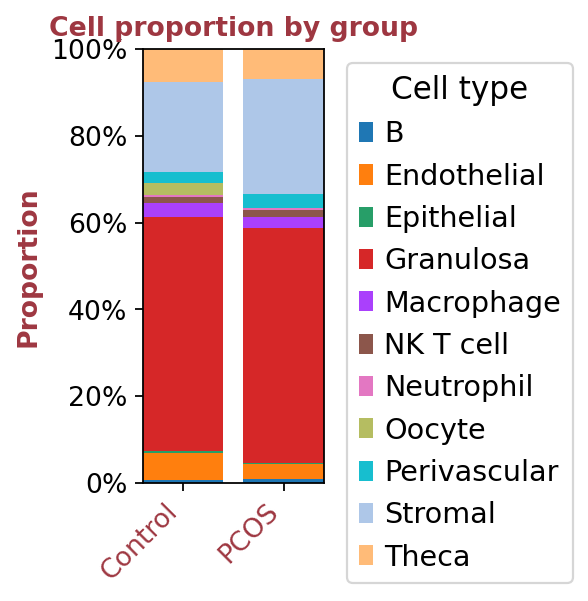

In [16]:
### 细胞比例图

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
#plt.rcParams['font.family'] = 'Arial'
# 假设 adata 已经加载并包含了必要的 obs 信息
# 确保 'cell_type' 和 'sample' 在 adata.obs 中

# 创建一个 DataFrame，包含 cell_type 和 sample 列
df = adata.obs[['Major_annotation_d', 'group']]

# 计算每个样本中每种细胞类型的数量
cell_counts = df.groupby(['group', 'Major_annotation_d']).size().unstack(fill_value=0)

# 计算每个样本中每种细胞类型的百分比
cell_percentages = cell_counts.div(cell_counts.sum(axis=1), axis=0)
print(cell_percentages)
# 绘制堆叠柱状图
fig, ax = plt.subplots(figsize=(4, 4))

# 使用 seaborn 的 stacked bar plot 功能 (需要通过累积和手动实现)
bottom = None
for idx, col in enumerate(cell_percentages.columns):
    if idx == 0:
        ax.bar(cell_percentages.index, cell_percentages[col], label=col)
        bottom = cell_percentages[col]
    else:
        ax.bar(cell_percentages.index, cell_percentages[col], bottom=bottom, label=col)
        bottom += cell_percentages[col]

# 设置图表标题和标签
ax.set_title('Cell proportion by group',weight='bold',color='#9e3741',fontsize=12)
ax.set_xlabel(None,color='#9e3741',weight='bold',fontsize=12)
ax.set_ylabel('Proportion',color='#9e3741',weight='bold',fontsize=12)
ax.grid(False)  # 完全移除网格线
# 或者
# ax.grid(True, linestyle='--')  # 将网格线变为虚线
# 旋转 x 轴标签 45 度并右对齐
plt.xticks(rotation=45, ha='right',color='#9e3741',fontsize=12)
plt.yticks(fontsize=12)
# 添加图例
plt.legend(title='Cell type', bbox_to_anchor=(1.05, 1), loc='upper left')
# 将图形两侧紧贴 y 轴
#ax.spines['left'].set_position(('data', -0.05))  # 调整左侧脊柱位置
#ax.spines['right'].set_visible(False)  # 隐藏右侧脊柱
#ax.spines['top'].set_visible(False)  # 隐藏顶部脊柱
# 修改 y 轴刻度标签为百分比格式（如 0% 到 100%）
def percent_formatter(x, pos):
    return f"{int(x * 100)}%"
ax.yaxis.set_major_formatter(mticker.FuncFormatter(percent_formatter))
# 可选：设置 y 轴刻度间隔为每 0.2（即 0%, 20%, ..., 100%）
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
# 设置 y 轴范围从 0 到 1，并且没有额外的扩展
ax.set_ylim(0, 1)
ax.margins(x=0)  # 消除 x 轴的空白区域
# 调整布局以避免遮挡
plt.tight_layout()
# 显示图形
plt.show()

/tmp/ipykernel_1379666/681591429.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = df.groupby(['sample', 'Major_annotation_d']).size().unstack(fill_value=0)


Major_annotation_d         B  Endothelial  Epithelial  Granulosa  Macrophage  \
sample                                                                         
GSM8302650          0.000450     0.033175    0.001169   0.593635    0.028500   
GSM8302651          0.002697     0.093257    0.008582   0.449939    0.037679   
GSM8302652          0.013772     0.062156    0.002754   0.580518    0.033970   
GSM8302653          0.023652     0.028070    0.000650   0.607277    0.028850   
GSM8302654          0.003777     0.037553    0.000971   0.538146    0.023524   
GSM8302655          0.003446     0.037314    0.003544   0.493453    0.026386   

Major_annotation_d  NK T cell  Neutrophil    Oocyte  Perivascular   Stromal  \
sample                                                                        
GSM8302650           0.012137    0.001978  0.079655      0.024184  0.188348   
GSM8302651           0.011443    0.003678  0.003024      0.025092  0.215284   
GSM8302652           0.020107    0.002846  

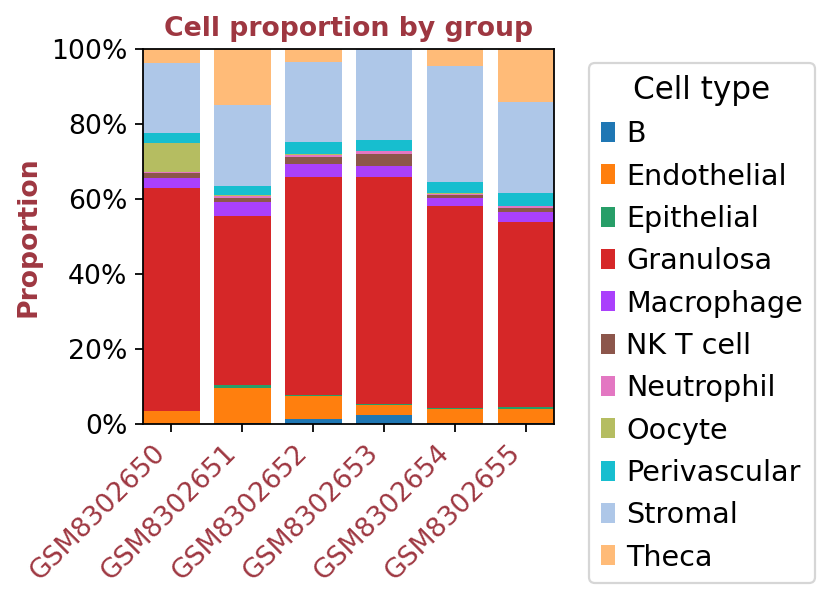

In [17]:
### 细胞比例图

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
#plt.rcParams['font.family'] = 'Arial'
# 假设 adata 已经加载并包含了必要的 obs 信息
# 确保 'cell_type' 和 'sample' 在 adata.obs 中

# 创建一个 DataFrame，包含 cell_type 和 sample 列
df = adata.obs[['Major_annotation_d', 'sample']]

# 计算每个样本中每种细胞类型的数量
cell_counts = df.groupby(['sample', 'Major_annotation_d']).size().unstack(fill_value=0)

# 计算每个样本中每种细胞类型的百分比
cell_percentages = cell_counts.div(cell_counts.sum(axis=1), axis=0)
print(cell_percentages)
# 绘制堆叠柱状图
fig, ax = plt.subplots(figsize=(5.5, 4))

# 使用 seaborn 的 stacked bar plot 功能 (需要通过累积和手动实现)
bottom = None
for idx, col in enumerate(cell_percentages.columns):
    if idx == 0:
        ax.bar(cell_percentages.index, cell_percentages[col], label=col)
        bottom = cell_percentages[col]
    else:
        ax.bar(cell_percentages.index, cell_percentages[col], bottom=bottom, label=col)
        bottom += cell_percentages[col]

# 设置图表标题和标签
ax.set_title('Cell proportion by group',weight='bold',color='#9e3741',fontsize=12)
ax.set_xlabel(None,color='#9e3741',weight='bold',fontsize=12)
ax.set_ylabel('Proportion',color='#9e3741',weight='bold',fontsize=12)
ax.grid(False)  # 完全移除网格线
# 或者
# ax.grid(True, linestyle='--')  # 将网格线变为虚线
# 旋转 x 轴标签 45 度并右对齐
plt.xticks(rotation=45, ha='right',color='#9e3741',fontsize=12)
plt.yticks(fontsize=12)
# 添加图例
plt.legend(title='Cell type', bbox_to_anchor=(1.05, 1), loc='upper left')
# 将图形两侧紧贴 y 轴
#ax.spines['left'].set_position(('data', -0.05))  # 调整左侧脊柱位置
#ax.spines['right'].set_visible(False)  # 隐藏右侧脊柱
#ax.spines['top'].set_visible(False)  # 隐藏顶部脊柱
# 修改 y 轴刻度标签为百分比格式（如 0% 到 100%）
def percent_formatter(x, pos):
    return f"{int(x * 100)}%"
ax.yaxis.set_major_formatter(mticker.FuncFormatter(percent_formatter))
# 可选：设置 y 轴刻度间隔为每 0.2（即 0%, 20%, ..., 100%）
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
# 设置 y 轴范围从 0 到 1，并且没有额外的扩展
ax.set_ylim(0, 1)
ax.margins(x=0)  # 消除 x 轴的空白区域
# 调整布局以避免遮挡
plt.tight_layout()
# 显示图形
plt.show()

### 大类差异分析

In [150]:
adata=sc.read_h5ad('./04_double_cell_remove/adata_after_double.h5ad')

In [151]:
adata.uns['log1p']['base'] =None
sc.tl.rank_genes_groups(
    adata, "Major_annotation_d", method="wilcoxon",key_added='dea_Major_annotation_1'
    ,use_raw=True  #默认就是用这个
)

In [152]:
### 导出差异分析结果
groups=adata.uns['dea_Major_annotation_1']['names'].dtype.names

with pd.ExcelWriter('./05_Major_annotation/Major_annotation_d_dea_results.xlsx') as writer:
    for group in groups:
        df=sc.get.rank_genes_groups_df(adata,group=group,key='dea_Major_annotation_1')
        df['group']=group
        ### 保存excel表格
        df.to_excel(writer,sheet_name=group)
    



findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

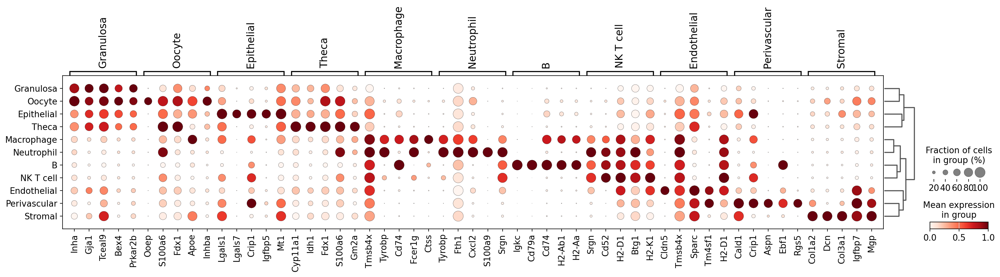

In [154]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby="Major_annotation_d",
    key='dea_Major_annotation_1',
    standard_scale="var",
    n_genes=5,
    show=False
)
plt.show()

In [ ]:
adata.write('./04_double_cell_remove/adata_after_double.h5ad')  ### 注释过的数据